In [44]:
!pip install pandas pyarrow

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

##### Loading the of the DataSet

In [29]:
import fsspec
from zipfile import ZipFile
from io import BytesIO

#-----------Function to load  a specific file form the zip file-----------
def load_specific_parquet(url):
    with fsspec.open(url, 'rb') as f:
        return pd.read_parquet(f)

#-----------link of the zip file from the google cloud-----------
url = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"
url2 = 'Data_2023.parquet'
#---------calling the function-----------------
metro_24_25 = load_specific_parquet(url)
metro_23 = load_specific_parquet(url2)
data1 = metro_24_25.copy()


In [30]:
# concatinating the 2023 data with the 2024-2025 data
data = pd.concat([data1, metro_23], ignore_index=True)

# Removing the 2022 data from the dataset
data = data[data['year']!=2022]

In [12]:
data['Route'].unique()

array(['New York City->Chicago', 'Chicago->New York City'], dtype=object)

In [31]:
# Taking only year-month-day
data['FlightDate_ET'] = data['FlightDate_ET'].dt.date

# checked all airport are from US (K)
data = data.iloc[:,1:]

# combining the fromMetro and toMetro to make it a route
data['Route'] = data['FromMetro']+'->'+data['ToMetro']

# filtering only the routes ['South Florida->Chicago', 'Chicago->South Florida']
data = data[data['Route'].isin(['Dallas->South Florida', 'South Florida->Dallas'])]

# 1. Ensure date format and extract Year/Month
data['FlightDate_ET'] = pd.to_datetime(data['FlightDate_ET'])
data['Month_Name'] = data['FlightDate_ET'].dt.strftime('%b')

# 2. Define the chronological order for months (Jan to Dec)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
data['Month_Name'] = pd.Categorical(data['Month_Name'], categories=month_order, ordered=True)



##### Creating a plot to compare the flights flown from between 'South Florida->Chicago', 'Chicago->South Florida' and vice vers
1. On Number of flights flown between this corriders

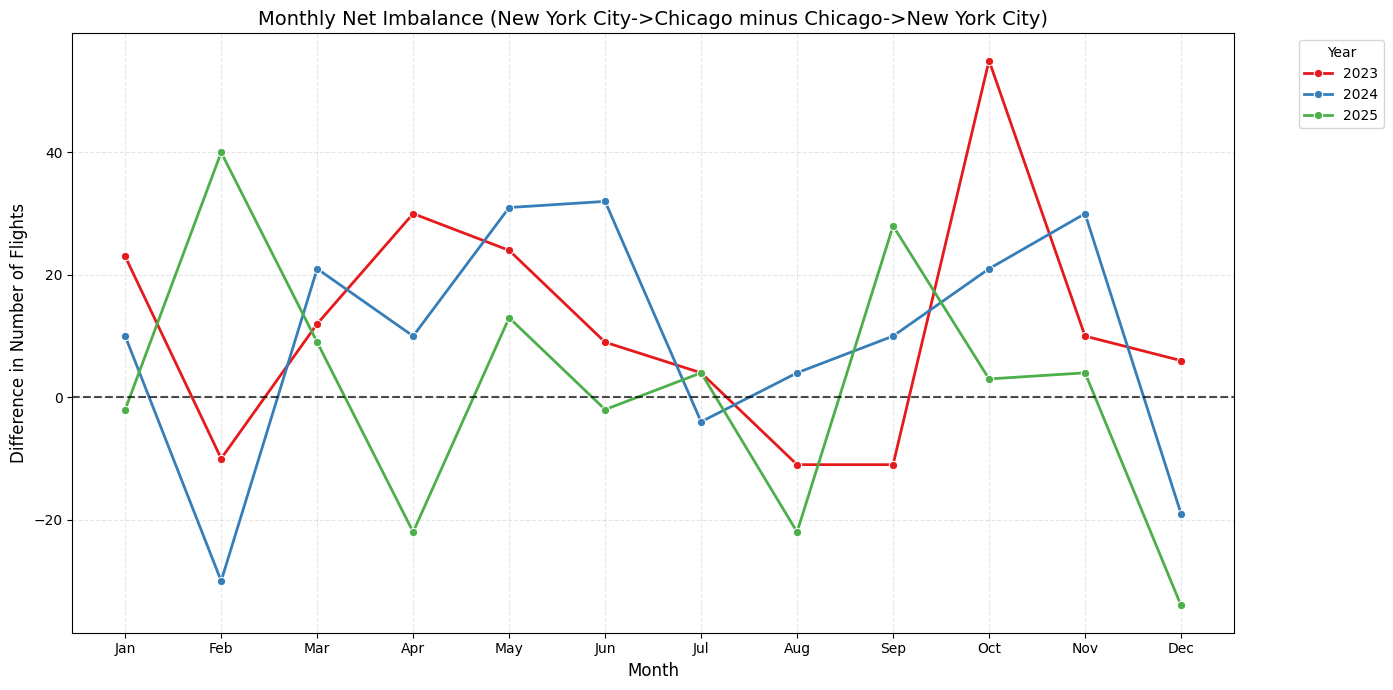

In [13]:
# 1. Aggregate flight counts by Route, Year, and Month (as you did)
imbalance_data = data.groupby(['Route', 'year', 'Month_Name']).size().reset_index(name='Flight Count')

# 2. Pivot the data to get routes into separate columns for subtraction
pivot_monthly = imbalance_data.pivot_table(index=['year', 'Month_Name'], columns='Route', 
    values='Flight Count', fill_value=0 ).reset_index()

# 3. Calculate the Net Difference (Positive = More Northbound | Negative = More Southbound)
pivot_monthly['Net_Imbalance']=(pivot_monthly['New York City->Chicago'] - pivot_monthly['Chicago->New York City'])

# 4. Create the Line Chart for the Difference
plt.figure(figsize=(14, 7))
sns.lineplot(data=pivot_monthly, x='Month_Name', y='Net_Imbalance', hue='year', 
    palette='Set1', marker='o', linewidth=2 )

# Add a horizontal line at 0 to show the balance point
plt.axhline(0, color='black', linestyle='--', alpha=0.7)

plt.title('Monthly Net Imbalance (New York City->Chicago minus Chicago->New York City)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Difference in Number of Flights', fontsize=12)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

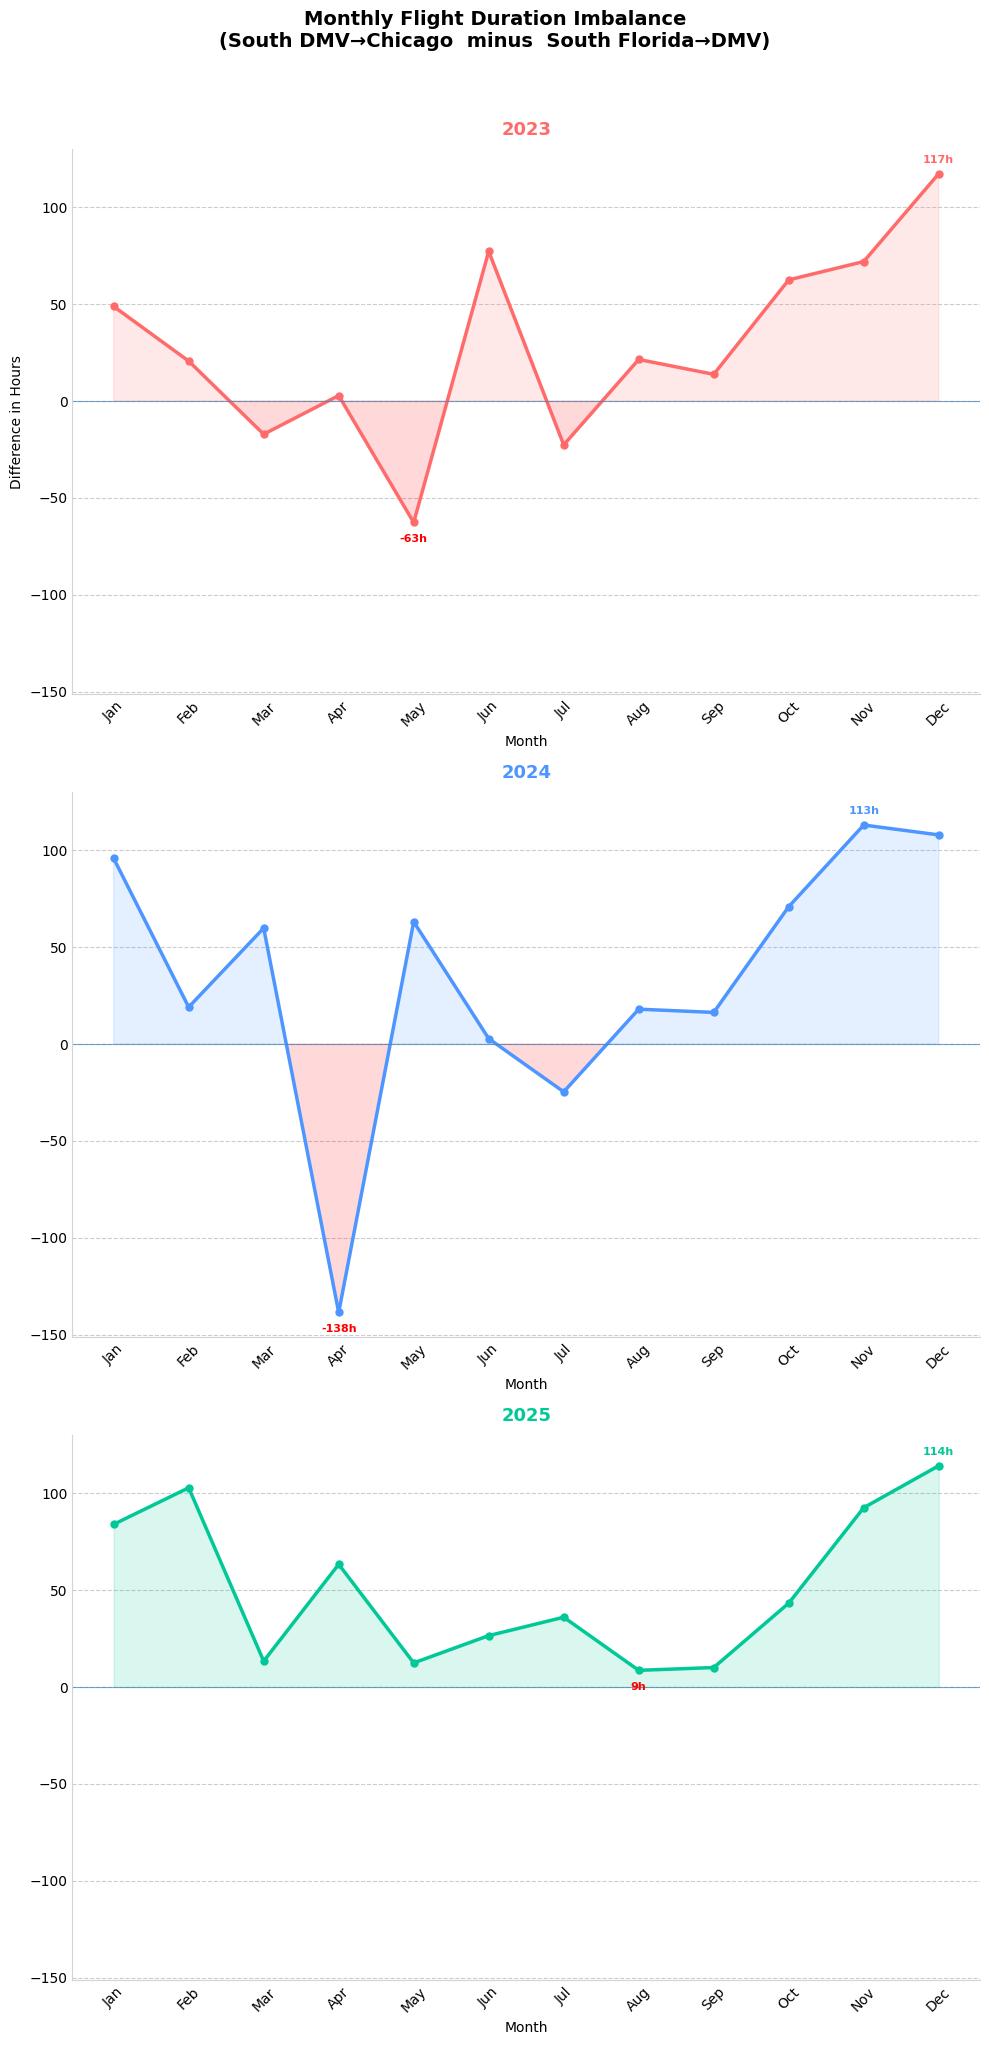

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Setup ---
years = [2023, 2024, 2025]
colors = ['#FF6B6B', '#4D96FF', '#00C897']  # light → mid → dark blue
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(3, 1, figsize=(10, 20), sharey=True)
fig.suptitle('Monthly Flight Duration Imbalance\n(New York City→Chicago  minus  Chicago→New York City)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, year, color in zip(axes, years, colors):

    # --- Filter & aggregate ---
    df_year = data[data['year'] == year].copy()

    duration_data = df_year.groupby(['Route', 'Month_Name'])['Hours'].sum().reset_index()

    pivot = duration_data.pivot_table(index='Month_Name', columns='Route',
                                      values='Hours').reset_index()

    # Ensure columns exist
    if 'New York City->Chicago' not in pivot.columns:
        pivot['New York City->Chicago'] = 0
    if 'Chicago->New York City' not in pivot.columns:
        pivot['Chicago->New York City'] = 0

    pivot['Duration_Diff_Hours'] = (
        pivot['New York City->Chicago'] - pivot['Chicago->New York City']
    )

    # --- Sort months correctly ---
    pivot['Month_Name'] = pd.Categorical(pivot['Month_Name'],
                                          categories=month_order, ordered=True)
    pivot = pivot.sort_values('Month_Name').dropna(subset=['Duration_Diff_Hours'])

    # --- Plot line ---
    ax.plot(pivot['Month_Name'], pivot['Duration_Diff_Hours'],
            color=color, linewidth=2.5, marker='o', markersize=5, label=str(year))

    # --- Zero reference line ---
    ax.axhline(0, color='steelblue', linewidth=0.8, linestyle='-', alpha=0.7)

    # --- Fill above/below zero ---
    ax.fill_between(pivot['Month_Name'], pivot['Duration_Diff_Hours'], 0,
                    where=(pivot['Duration_Diff_Hours'] >= 0),
                    alpha=0.15, color=color, interpolate=True)
    ax.fill_between(pivot['Month_Name'], pivot['Duration_Diff_Hours'], 0,
                    where=(pivot['Duration_Diff_Hours'] < 0),
                    alpha=0.15, color='red', interpolate=True)

    # --- Styling ---
    ax.set_title(str(year), fontsize=13, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Difference in Hours' if ax == axes[0] else '', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='grey')
    ax.set_axisbelow(True)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('lightgrey')
    ax.spines['bottom'].set_color('lightgrey')
    ax.tick_params(axis='both', length=0)

    # --- Annotate max and min points ---
    max_idx = pivot['Duration_Diff_Hours'].idxmax()
    min_idx = pivot['Duration_Diff_Hours'].idxmin()

    ax.annotate(f"{pivot.loc[max_idx, 'Duration_Diff_Hours']:.0f}h",
                xy=(pivot.loc[max_idx, 'Month_Name'],
                    pivot.loc[max_idx, 'Duration_Diff_Hours']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color=color, fontweight='bold')

    ax.annotate(f"{pivot.loc[min_idx, 'Duration_Diff_Hours']:.0f}h",
                xy=(pivot.loc[min_idx, 'Month_Name'],
                    pivot.loc[min_idx, 'Duration_Diff_Hours']),
                xytext=(0, -14), textcoords='offset points',
                ha='center', fontsize=8, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

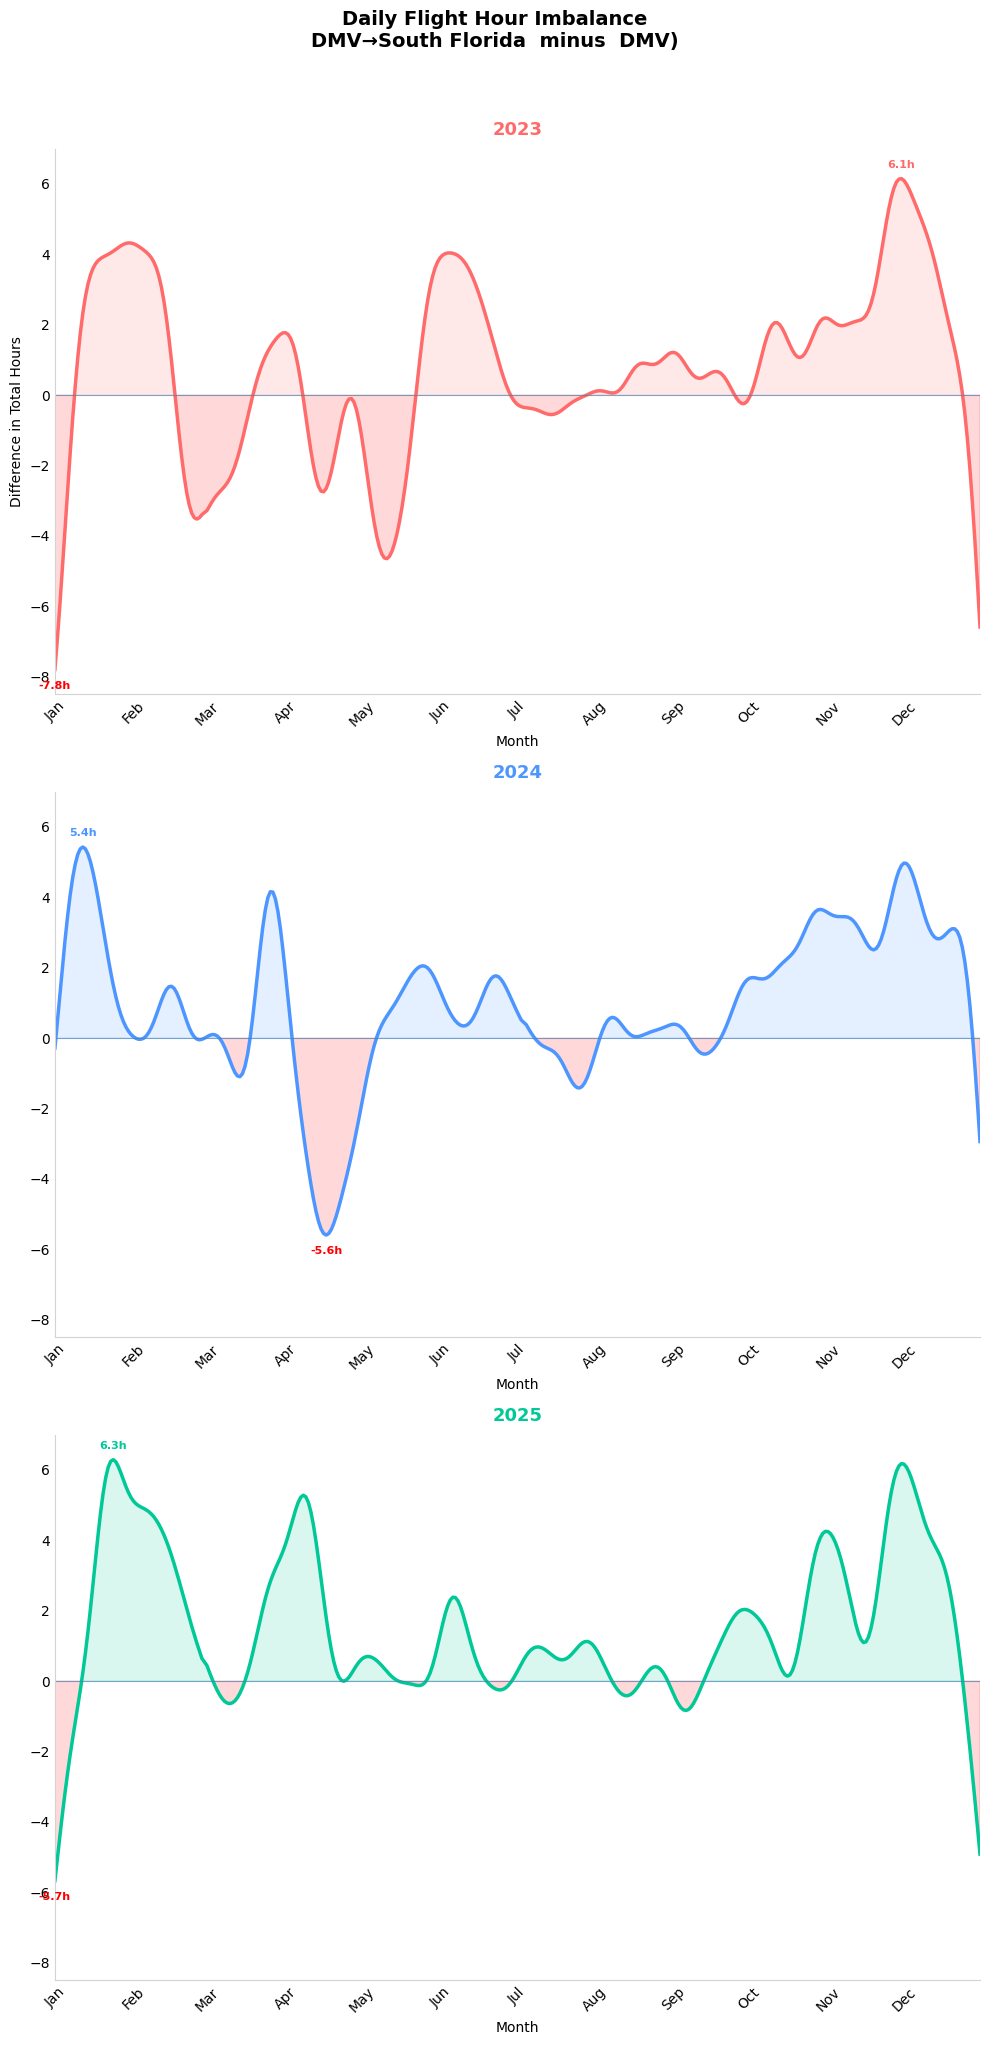

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from scipy.ndimage import gaussian_filter1d

# --- Setup ---
years = [2023, 2024, 2025]
colors = ['#FF6B6B', '#4D96FF', '#00C897']  # light → mid → dark blue

def compute_daily_net(data, year):
    df = data[data['year'] == year].copy()

    daily = df.groupby(['Route', 'FlightDate_ET'])['Hours'].sum().reset_index()

    pivot = daily.pivot_table(index='FlightDate_ET', columns='Route',
                              values='Hours', fill_value=0).reset_index()

    # Ensure both route columns exist
    if 'DMV->South Florida' not in pivot.columns:
        pivot['DMV->South Florida'] = 0
    if 'South Florida->DMV' not in pivot.columns:
        pivot['South Florida->DMV'] = 0

    pivot['Duration_Diff_Hour'] = (
        pivot['DMV->South Florida'] - pivot['South Florida->DMV']
    )

    # Map to dummy year 2024 for x-axis alignment
    pivot['Plot_Date'] = pivot['FlightDate_ET'].apply(lambda x: x.replace(year=2024))
    pivot = pivot.sort_values('Plot_Date')

    # Remove months with fewer than 5 days of data (prevents edge distortion)
    pivot['month'] = pivot['Plot_Date'].dt.month
    month_counts = pivot.groupby('month')['Duration_Diff_Hour'].count()
    valid_months = month_counts[month_counts >= 5].index
    pivot = pivot[pivot['month'].isin(valid_months)]

    return pivot[['Plot_Date', 'Duration_Diff_Hour']]


def smooth(series, sigma=6):
    """Gaussian smoothing with nearest mode to prevent edge bleeding."""
    return gaussian_filter1d(series.values.astype(float), sigma=sigma, mode='nearest')


# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(10, 20), sharey=True)
fig.suptitle('Daily Flight Hour Imbalance\nDMV→South Florida  minus  DMV)',
             fontsize=14, fontweight='bold', y=1.02)


for ax, year, color in zip(axes, years, colors):

    df_y = compute_daily_net(data, year)

    if df_y.empty:
        ax.set_title(f'{year}\n(No Data)', fontsize=12)
        continue

    y_smooth = smooth(df_y['Duration_Diff_Hour'], sigma=6)



    # --- Smoothed line (bold) ---
    ax.plot(df_y['Plot_Date'], y_smooth,
            color=color, linewidth=2.5, label=str(year))

    # --- Zero reference line ---
    ax.axhline(0, color='steelblue', linewidth=0.8, linestyle='-', alpha=0.7)

    # --- Fill above/below zero ---
    ax.fill_between(df_y['Plot_Date'], y_smooth, 0,
                    where=(y_smooth >= 0),
                    alpha=0.15, color=color, interpolate=True)
    ax.fill_between(df_y['Plot_Date'], y_smooth, 0,
                    where=(y_smooth < 0),
                    alpha=0.15, color='red', interpolate=True)

    # --- Annotate max and min of smoothed line ---
    max_idx = np.argmax(y_smooth)
    min_idx = np.argmin(y_smooth)

    ax.annotate(f"{y_smooth[max_idx]:.1f}h",
                xy=(df_y['Plot_Date'].iloc[max_idx], y_smooth[max_idx]),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color=color, fontweight='bold')

    ax.annotate(f"{y_smooth[min_idx]:.1f}h",
                xy=(df_y['Plot_Date'].iloc[min_idx], y_smooth[min_idx]),
                xytext=(0, -14), textcoords='offset points',
                ha='center', fontsize=8, color='red', fontweight='bold')

    # --- X-axis formatting ---
    ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(axis='x', rotation=45)

    # --- Styling ---
    ax.set_title(str(year), fontsize=13, fontweight='bold', color=color, pad=10)
    ax.set_xlabel('Month', fontsize=10)
    ax.set_ylabel('Difference in Total Hours' if ax == axes[0] else '', fontsize=10)
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('lightgrey')
    ax.spines['bottom'].set_color('lightgrey')
    ax.tick_params(axis='both', length=0)

plt.tight_layout()
plt.show()

In [65]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# import numpy as np
# from scipy.ndimage import gaussian_filter1d

# def compute_net_travel(data, year):
#     df = data[data['year'] == year].copy()
#     daily = df.groupby(['Route', 'FlightDate_ET'])['Hours'].sum().reset_index()
#     pivot = daily.pivot_table(index='FlightDate_ET', columns='Route',
#                               values='Hours', fill_value=0).reset_index()

#     # Ensure both route columns exist
#     if 'South Florida->Chicago' not in pivot.columns:
#         pivot['South Florida->Chicago'] = 0
#     if 'Chicago->South Florida' not in pivot.columns:
#         pivot['Chicago->South Florida'] = 0

#     pivot['Net'] = pivot['South Florida->Chicago'] - pivot['Chicago->South Florida']

#     # Map all dates to a common dummy year (2024) for x-axis alignment
#     pivot['Plot_Date'] = pivot['FlightDate_ET'].apply(lambda x: x.replace(year=2024))
#     pivot = pivot.sort_values('Plot_Date')
#     return pivot[['Plot_Date', 'Net']]


# def smooth(series, sigma=6):
#     """Apply Gaussian smoothing to replicate the curved look in the chart."""
#     return gaussian_filter1d(series.values.astype(float), sigma=sigma,mode='nearest')


# # --- Build per-year series ---
# years   = [2025, 2024, 2023]
# colors = ['#FF6B6B', '#4D96FF', '#00C897']   # dark blue → mid blue → light blue/grey
# lwidths = [2.5,   1.8,   1.5]

# fig, ax = plt.subplots(figsize=(13, 6))

# for year, color, lw in zip(years, colors, lwidths):
#     df_y = compute_net_travel(data, year)
#     if df_y.empty:
#         continue
#     y_smooth = smooth(df_y['Net'], sigma=6)
#     ax.plot(df_y['Plot_Date'], y_smooth,
#             color=color, linewidth=lw, label=str(year))

# # --- Zero reference line ---
# ax.axhline(0, color='steelblue', linewidth=0.8, linestyle='-', alpha=0.7)

# # --- X-axis: Feb → Jul to match the image ---
# ax.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
# ax.xaxis.set_major_locator(mdates.MonthLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# # --- Arrow on right end of x-axis (cosmetic, like the image) ---
# ax.annotate('', xy=(1.01, 0), xycoords='axes fraction',
#             xytext=(0.99, 0), textcoords='axes fraction',
#             arrowprops=dict(arrowstyle='->', color='grey', lw=1.2))

# # --- Labels & legend ---
# ax.set_title('Net Travel', fontsize=13, pad=10)
# ax.set_ylabel('Hours (k)', fontsize=10)
# ax.set_xlabel('')
# ax.legend(title='', loc='center right',
#           labels=[str(y) for y in years],
#           frameon=True, fontsize=10)

# # --- Grid & spines ---
# ax.yaxis.grid(Fa)
# ax.set_axisbelow(True)
# for spine in ['top', 'right', 'bottom']:
#     ax.spines[spine].set_visible(False)
# ax.spines['left'].set_visible(False)
# ax.tick_params(axis='both', length=0)

# plt.tight_layout()
# plt.show()

### Positive Values (above 0)

- More hours flown from South Florida → Chicago than Chicago → South Florida
- Means more travel demand going North (Florida to Chicago)
- Example: +10k hours = FL→CHI flights had 10k more hours than CHI→FL flights


### Negative Values (below 0)

- More hours flown from Chicago → South Florida than South Florida → Chicago
- Means more travel demand going South (Chicago to Florida)
- Example: -10k hours = CHI→FL flights had 10k more hours than FL→CHI flights


### Zero Line (0)

- Perfectly balanced — equal flight hours in both directions
- No net imbalance between the two routes

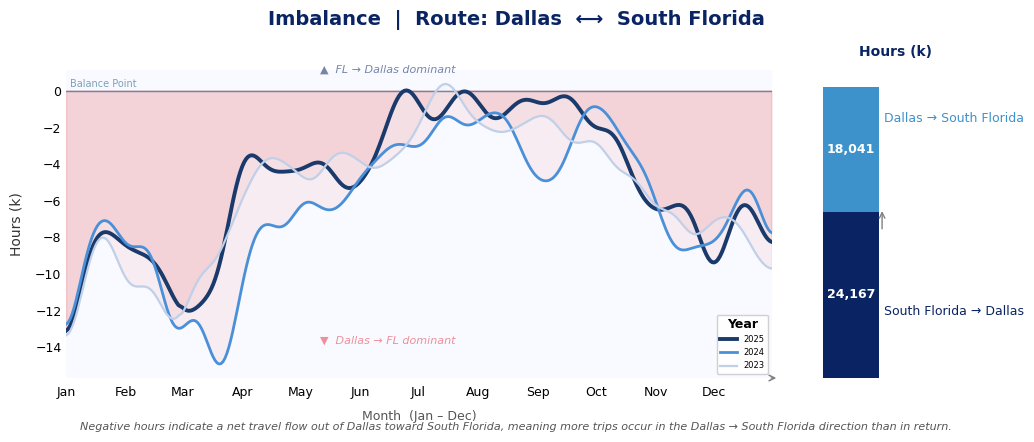

In [33]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.dates as mdates
# import matplotlib.gridspec as gridspec
# import numpy as np
# from scipy.ndimage import gaussian_filter1d

# import fsspec
# from zipfile import ZipFile
# from io import BytesIO

# #-----------Function to load  a specific file form the zip file-----------
# def load_specific_parquet(url):
#     with fsspec.open(url, 'rb') as f:
#         return pd.read_parquet(f)

# #-----------link of the zip file from the google cloud-----------
# url = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"
# url2 = 'Data_2023.parquet'
# #---------calling the function-----------------
# metro_24_25 = load_specific_parquet(url)
# metro_23 = load_specific_parquet(url2)
# data1 = metro_24_25.copy()

# # concatinating the 2023 data with the 2024-2025 data
# data = pd.concat([data1, metro_23], ignore_index=True)

# # Removing the 2022 data from the dataset
# data = data[data['year']!=2022]
# #___________________________________________________________________________
# # Taking only year-month-day
# data['FlightDate_ET'] = data['FlightDate_ET'].dt.date

# # checked all airport are from US (K)
# data = data.iloc[:,1:]

# # combining the fromMetro and toMetro to make it a route
# data['Route'] = data['FromMetro']+'->'+data['ToMetro']

# # filtering only the routes ['South Florida->Chicago', 'Chicago->South Florida']
# data = data[data['Route'].isin(['New York City->Chicago', 'Chicago->New York City'])]

# # 1. Ensure date format and extract Year/Month
# data['FlightDate_ET'] = pd.to_datetime(data['FlightDate_ET'])
# data['Month_Name'] = data['FlightDate_ET'].dt.strftime('%b')

# # 2. Define the chronological order for months (Jan to Dec)
# month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# data['Month_Name'] = pd.Categorical(data['Month_Name'], categories=month_order, ordered=True)


# ── Helpers ────────────────────────────────────────────────────────────────────
def compute_net_travel(data, year):
    df = data[data['year'] == year].copy()
    daily = df.groupby(['Route', 'FlightDate_ET'])['Hours'].sum().reset_index()
    pivot = daily.pivot_table(index='FlightDate_ET', columns='Route',
                              values='Hours', fill_value=0).reset_index()
    if 'Dallas->South Florida' not in pivot.columns:
        pivot['Dallas->South Florida'] = 0
    if 'South Florida->Dallas' not in pivot.columns:
        pivot['South Florida->Dallas'] = 0
    pivot['Net'] = pivot['Dallas->South Florida'] - pivot['South Florida->Dallas']
    pivot['Plot_Date'] = pivot['FlightDate_ET'].apply(lambda x: x.replace(year=2024))
    pivot = pivot.sort_values('Plot_Date')

    # Remove sparse months
    pivot['month'] = pivot['Plot_Date'].dt.month
    month_counts = pivot.groupby('month')['Net'].count()
    valid_months = month_counts[month_counts >= 3].index
    pivot = pivot[pivot['month'].isin(valid_months)]
    return pivot[['Plot_Date', 'Net']]


def smooth(series, sigma=8):
    return gaussian_filter1d(series.values.astype(float), sigma=sigma, mode='reflect')


# ── Figure Layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 4), facecolor='white')
gs  = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.05)

ax_line = fig.add_subplot(gs[0])   # Left: line chart
ax_bar  = fig.add_subplot(gs[1])   # Right: stacked bar
ax_line.set_facecolor('#f8faff')
ax_bar.set_facecolor('white')

# ══════════════════════════════════════════════════════════════════════════════
# LEFT — Net Travel Line Chart
# ══════════════════════════════════════════════════════════════════════════════
years   = [2025, 2024, 2023]
colors  = ['#1a3a6b', '#4a90d9', '#c0d0e8']
lwidths = [2.8, 2.0, 1.6]
lstyles = ['-', '-', '-']

for year, color, lw, ls in zip(years, colors, lwidths, lstyles):
    df_y = compute_net_travel(data, year)
    if df_y.empty:
        continue
    y_smooth = smooth(df_y['Net'], sigma=8)


    # Smoothed line
    ax_line.plot(df_y['Plot_Date'], y_smooth,
                 color=color, linewidth=lw, linestyle=ls, label=str(year), zorder=3)

    # Fill above/below zero
    ax_line.fill_between(df_y['Plot_Date'], y_smooth, 0,
                         where=(y_smooth >= 0), alpha=0.07, color=color, interpolate=True)
    ax_line.fill_between(df_y['Plot_Date'], y_smooth, 0,
                         where=(y_smooth < 0), alpha=0.07, color='#e63946', interpolate=True)

# Zero line
ax_line.axhline(0, color='#457b9d', linewidth=1.0, alpha=0.8, zorder=2)
ax_line.text(pd.Timestamp('2024-01-03'), 0.2, 'Balance Point',
             fontsize=7, color='#457b9d', alpha=0.7)

# X-axis
ax_line.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
ax_line.xaxis.set_major_locator(mdates.MonthLocator())
ax_line.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax_line.tick_params(axis='x', labelsize=9, length=0, pad=6)
ax_line.tick_params(axis='y', labelsize=9, length=0)

# Arrow on x-axis
ax_line.annotate('', xy=(1.01, 0), xycoords='axes fraction',
                 xytext=(0.995, 0), textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', color='grey', lw=1.1))

# Labels
ax_line.set_title('', fontsize=13, fontweight='bold',
                  color='#0a2463', pad=10, loc='center')
ax_line.set_ylabel('Hours (k)', fontsize=10, color='#333333', labelpad=8)
ax_line.set_xlabel('Month  (Jan – Dec)', fontsize=9, color='#555555', labelpad=8)

# Legend
legend = ax_line.legend(title='Year', loc='lower right', frameon=True,
                        fontsize=6, title_fontsize=9,
                        framealpha=0.9, edgecolor='#cccccc')
legend.get_title().set_fontweight('bold')

# Grid & spines
ax_line.yaxis.grid(False)
ax_line.xaxis.grid(False)
ax_line.set_axisbelow(True)
for spine in ['top', 'right', 'bottom', 'left']:
    ax_line.spines[spine].set_visible(False)

# Zone labels
y_top = ax_line.get_ylim()[1]
y_bot = ax_line.get_ylim()[0]
ax_line.text(pd.Timestamp('2024-06-15'), y_top * 0.88,
             '▲  FL → Dallas dominant', fontsize=8, color='#0a2463',
             alpha=0.55, ha='center', style='italic')
ax_line.text(pd.Timestamp('2024-06-15'), y_bot * 0.88,
             '▼  Dallas → FL dominant', fontsize=8, color='#e63946',
             alpha=0.55, ha='center', style='italic')

# ══════════════════════════════════════════════════════════════════════════════
# RIGHT — Stacked Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
route_summary = data.groupby('Route').agg(Total_Hours=('Hours', 'sum')).reset_index()

fl_chi  = route_summary[route_summary['Route'] == 'Dallas->South Florida'].iloc[0]
chi_fl  = route_summary[route_summary['Route'] == 'South Florida->Dallas'].iloc[0]

fl_chi_hours = fl_chi['Total_Hours']
chi_fl_hours = chi_fl['Total_Hours']


bar_width = 0.5
x = 0.5

# Bottom bar: CHI → FL (dark navy)
ax_bar.bar(x, chi_fl_hours, width=bar_width, color='#0a2463', zorder=3)

# Top bar: FL → CHI (bright blue)
ax_bar.bar(x, fl_chi_hours, width=bar_width, bottom=chi_fl_hours,
           color='#3e92cc', zorder=3)

# Inside labels: hours + flight count
ax_bar.text(x, chi_fl_hours / 2,
            f'{chi_fl_hours:,.0f}',
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=4)

ax_bar.text(x, chi_fl_hours + fl_chi_hours / 2,
            f'{fl_chi_hours:,.0f}',
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=4)

# Route labels on the right
ax_bar.text(x + bar_width / 2 + 0.05,
            chi_fl_hours + fl_chi_hours * 0.75,
            'Dallas → South Florida', fontsize=9, color='#3e92cc',
            va='center', ha='left')

ax_bar.text(x + bar_width / 2 + 0.05,
            chi_fl_hours * 0.4,
            'South Florida → Dallas', fontsize=9, color='#0a2463',
            va='center', ha='left')

# Arrow between route labels
ax_bar.annotate('', xy=(x + bar_width / 2 + 0.03, chi_fl_hours * 1.02),
                xytext=(x + bar_width / 2 + 0.03, chi_fl_hours * 0.88),
                arrowprops=dict(arrowstyle='->', color='grey', lw=1.0))

# Title & clean axes
ax_bar.set_title('Hours (k)', fontsize=10, fontweight='bold',
                 color='#0a2463', pad=10)
ax_bar.set_xlim(0, 1.8)
ax_bar.set_ylim(0, (chi_fl_hours + fl_chi_hours) * 1.06)
ax_bar.axis('off')

# ── Footer note ────────────────────────────────────────────────────────────────
fig.text(0.5, -0.02,
         'Negative hours indicate a net travel flow out of Dallas toward South Florida, '
         'meaning more trips occur in the Dallas → South Florida direction than in return.',
         ha='center', fontsize=8, color='#555555', style='italic')

# ── Main title ─────────────────────────────────────────────────────────────────
fig.suptitle('Imbalance  |  Route: Dallas  ⟷  South Florida',
             fontsize=14, fontweight='bold', color='#0a2463', y=1.03)

plt.tight_layout()
plt.show()

In [23]:
data2 = data.groupby(['Route', 'FlightDate_ET']).agg({'Hours':'sum','Operator':'count'})
data2 = data2.reset_index().rename(columns={'Operator':'Flight Count'})
data2_pivot = data2.pivot_table(index='FlightDate_ET',columns='Route',values=['Hours','Flight Count'])
data2_pivot = data2_pivot.reset_index()
data2_pivot[('Hours', 'Hours Diff')] = (
     data2_pivot[('Hours', 'New York City->Chicago')]- data2_pivot[('Hours', 'Chicago->New York City')])
data2_pivot[data2_pivot[('Hours', 'Hours Diff')]<0]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
import fsspec

# ── Load Data ──────────────────────────────────────────────────────────────────
def load_specific_parquet(url):
    with fsspec.open(url, 'rb') as f:
        return pd.read_parquet(f)

url  = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"
url2 = 'gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_22_23_metro.parquet'

metro_24_25 = load_specific_parquet(url)
metro_23    = load_specific_parquet(url2)

Data = pd.concat([metro_24_25, metro_23], ignore_index=True)
Data = Data[Data['year'] != 2022]
Data = Data.iloc[:, 1:]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
import fsspec

# ── Load Data ──────────────────────────────────────────────────────────────────
def load_specific_parquet(url):
    with fsspec.open(url, 'rb') as f:
        return pd.read_parquet(f)

url  = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"
url2 = 'gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_22_23_metro.parquet'

metro_24_25 = load_specific_parquet(url)
metro_23    = load_specific_parquet(url2)

Data = pd.concat([metro_24_25, metro_23], ignore_index=True)
Data = Data[Data['year'] != 2022]
Data = Data.iloc[:, 1:]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
import fsspec

# ── Load Data ──────────────────────────────────────────────────────────────────
def load_specific_parquet(url):
    with fsspec.open(url, 'rb') as f:
        return pd.read_parquet(f)

url  = "gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_24_25_metro.parquet"
url2 = 'gs://agntworks-data-dev/wheelsup/processed/wingx/lj_smid_us_revenue_clean_22_23_metro.parquet'

metro_24_25 = load_specific_parquet(url)
metro_23    = load_specific_parquet(url2)

Data = pd.concat([metro_24_25, metro_23], ignore_index=True)
Data = Data[Data['year'] != 2022]
Data = Data.iloc[:, 1:]


In [82]:
data = Data.copy()
# ══════════════════════════════════════════════════════════════════════════════
# ✅ ONLY CHANGE THIS — Define your corridor here
# ══════════════════════════════════════════════════════════════════════════════
ROUTE_A = 'South Florida'   # From Metro
ROUTE_B = 'Dallas'         # To Metro
# ══════════════════════════════════════════════════════════════════════════════

# ── Auto-generate route strings ────────────────────────────────────────────────
ROUTE_AB = f'{ROUTE_A}->{ROUTE_B}'   # e.g. South Florida->Chicago
ROUTE_BA = f'{ROUTE_B}->{ROUTE_A}'   # e.g. Chicago->South Florida


# ── Preprocessing ──────────────────────────────────────────────────────────────
data['FlightDate_ET'] = pd.to_datetime(data['FlightDate_ET']).dt.normalize()
data['Route']         = data['FromMetro'] + '->' + data['ToMetro']
data['Month_Name']    = data['FlightDate_ET'].dt.strftime('%b')

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
data['Month_Name'] = pd.Categorical(data['Month_Name'],
                                     categories=month_order, ordered=True)

# ── Filter to selected corridor only ───────────────────────────────────────────
data = data[data['Route'].isin([ROUTE_AB, ROUTE_BA])]

if data.empty:
    raise ValueError(f"No data found for corridor: {ROUTE_AB} / {ROUTE_BA}. "
                     f"Please check your ROUTE_A and ROUTE_B values.")

# ── Helpers ────────────────────────────────────────────────────────────────────
def compute_net_travel(data, year, route_ab, route_ba):
    df = data[data['year'] == year].copy()
    daily = df.groupby(['Route', 'FlightDate_ET'])['Hours'].sum().reset_index()
    pivot = daily.pivot_table(index='FlightDate_ET', columns='Route',
                              values='Hours', fill_value=0).reset_index()

    if route_ab not in pivot.columns:
        pivot[route_ab] = 0
    if route_ba not in pivot.columns:
        pivot[route_ba] = 0

    # Net = A→B minus B→A
    pivot['Net'] = pivot[route_ab] - pivot[route_ba]
    pivot['Plot_Date'] = pivot['FlightDate_ET'].apply(lambda x: x.replace(year=2024))
    pivot = pivot.sort_values('Plot_Date')

    # Remove sparse months (< 5 days)
    pivot['month'] = pivot['Plot_Date'].dt.month
    month_counts   = pivot.groupby('month')['Net'].count()
    valid_months   = month_counts[month_counts >= 5].index
    pivot          = pivot[pivot['month'].isin(valid_months)]

    return pivot[['Plot_Date', 'Net']]


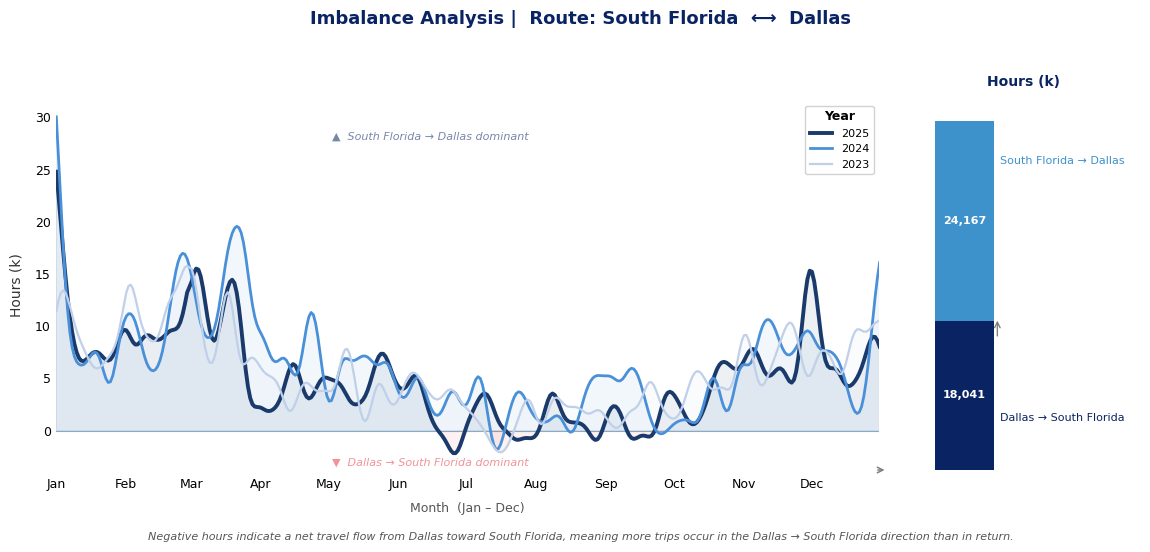

In [92]:
def smooth(series, sigma=10):
   # return savgol_filter(series.values, 9, 2)
   return gaussian_filter1d(series.values.astype(float), sigma=sigma, mode='nearest')

# ── Figure Layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5), facecolor='white')
gs  = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1], wspace=0.05)

ax_line = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])
ax_line.set_facecolor('white')
ax_bar.set_facecolor('white')

# ══════════════════════════════════════════════════════════════════════════════
# LEFT — Net Travel Line Chart
# ══════════════════════════════════════════════════════════════════════════════
years   = [2025, 2024, 2023]
colors  = ['#1a3a6b', '#4a90d9', '#c0d0e8']
lwidths = [2.8, 2.0, 1.6]
lstyles = ['-', '-', '-']

for year, color, lw, ls in zip(years, colors, lwidths, lstyles):
    df_y = compute_net_travel(data, year, ROUTE_AB, ROUTE_BA)
    if df_y.empty:
        continue
    y_smooth = smooth(df_y['Net'], sigma=3.5)

    ax_line.plot(df_y['Plot_Date'], y_smooth,
                 color=color, linewidth=lw, linestyle=ls,
                 label=str(year), zorder=3)

    ax_line.fill_between(df_y['Plot_Date'], y_smooth, 0,
                         where=(y_smooth >= 0),
                         alpha=0.07, color=color, interpolate=True)
    ax_line.fill_between(df_y['Plot_Date'], y_smooth, 0,
                         where=(y_smooth < 0),
                         alpha=0.07, color='#e63946', interpolate=True)

# Zero reference line
ax_line.axhline(0, color='#457b9d', linewidth=0.8, alpha=0.6, zorder=2)

# X-axis
ax_line.set_xlim(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'))
ax_line.xaxis.set_major_locator(mdates.MonthLocator())
ax_line.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax_line.tick_params(axis='x', labelsize=9, length=0, pad=6)
ax_line.tick_params(axis='y', labelsize=9, length=0)

# Arrow on x-axis
ax_line.annotate('', xy=(1.01, 0), xycoords='axes fraction',
                 xytext=(0.995, 0), textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', color='grey', lw=1.1))

# Labels
ax_line.set_ylabel('Hours (k)', fontsize=10, color='#333333', labelpad=8)
ax_line.set_xlabel('Month  (Jan – Dec)', fontsize=9, color='#555555', labelpad=8)

# Legend
legend = ax_line.legend(title='Year', loc='upper right', frameon=True,
                        fontsize=8, title_fontsize=9,
                        framealpha=0.9, edgecolor='#cccccc')
legend.get_title().set_fontweight('bold')

# No grid lines
ax_line.yaxis.grid(False)
ax_line.xaxis.grid(False)
for spine in ['top', 'right', 'left', 'bottom']:
    ax_line.spines[spine].set_visible(False)

# Zone labels (auto-use corridor names)
y_top = ax_line.get_ylim()[1]
y_bot = ax_line.get_ylim()[0]
ax_line.text(pd.Timestamp('2024-06-15'), y_top * 0.88,
             f'▲  {ROUTE_A} → {ROUTE_B} dominant',
             fontsize=8, color='#0a2463', alpha=0.55, ha='center', style='italic')
ax_line.text(pd.Timestamp('2024-06-15'), y_bot * 0.88,
             f'▼  {ROUTE_B} → {ROUTE_A} dominant',
             fontsize=8, color='#e63946', alpha=0.55, ha='center', style='italic')

# ══════════════════════════════════════════════════════════════════════════════
# RIGHT — Stacked Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
route_summary = data.groupby('Route').agg(
    Total_Hours=('Hours', 'sum'),
    Flight_Count=('Hours', 'count')
).reset_index()

ab_row = route_summary[route_summary['Route'] == ROUTE_AB]
ba_row = route_summary[route_summary['Route'] == ROUTE_BA]

ab_hours = ab_row['Total_Hours'].values[0] if not ab_row.empty else 0
ba_hours = ba_row['Total_Hours'].values[0] if not ba_row.empty else 0
ab_count = ab_row['Flight_Count'].values[0] if not ab_row.empty else 0
ba_count = ba_row['Flight_Count'].values[0] if not ba_row.empty else 0

bar_width = 0.5
x = 0.5

# Bottom bar: B→A (dark navy)
ax_bar.bar(x, ba_hours, width=bar_width, color='#0a2463', zorder=3)

# Top bar: A→B (bright blue)
ax_bar.bar(x, ab_hours, width=bar_width, bottom=ba_hours,
           color='#3e92cc', zorder=3)

# Inside labels
ax_bar.text(x, ba_hours / 2,
            f'{ba_hours:,.0f}',
            ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=4)

ax_bar.text(x, ba_hours + ab_hours / 2,
            f'{ab_hours:,.0f}',
            ha='center', va='center',
            fontsize=8, fontweight='bold', color='white', zorder=4)

# Route labels on the right (auto-named)
ax_bar.text(x + bar_width / 2 + 0.05,
            ba_hours + ab_hours * 0.80,
            f'{ROUTE_A} → {ROUTE_B}',
            fontsize=8, color='#3e92cc', va='center', ha='left')

ax_bar.text(x + bar_width / 2 + 0.05,
            ba_hours * 0.35,
            f'{ROUTE_B} → {ROUTE_A}',
            fontsize=8, color='#0a2463', va='center', ha='left')

# Arrow
ax_bar.annotate('', xy=(x + bar_width / 2 + 0.03, ba_hours * 1.02),
                xytext=(x + bar_width / 2 + 0.03, ba_hours * 0.88),
                arrowprops=dict(arrowstyle='->', color='grey', lw=1.0))

# Bar title & clean axes
ax_bar.set_title('Hours (k)', fontsize=10, fontweight='bold',
                 color='#0a2463', pad=10)
ax_bar.set_xlim(0, 2.0)
ax_bar.set_ylim(0, (ba_hours + ab_hours) * 1.06)
ax_bar.axis('off')

# ── Footer ─────────────────────────────────────────────────────────────────────
fig.text(0.5, -0.03,
         f'Negative hours indicate a net travel flow from {ROUTE_B} toward {ROUTE_A}, '
         f'meaning more trips occur in the {ROUTE_B} → {ROUTE_A} direction than in return.',
         ha='center', fontsize=8, color='#555555', style='italic')

# ── Main Title (auto-named) ────────────────────────────────────────────────────
fig.suptitle(f'Imbalance Analysis |  Route: {ROUTE_A}  ⟷  {ROUTE_B}',
             fontsize=13, fontweight='bold', color='#0a2463', y=1.03)

plt.subplots_adjust(wspace=0.2, hspace=0.2, top=0.85)
plt.show()

/var/tmp/ipykernel_6491/2483253680.py:23: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data['Month'] = data['FlightDate_ET'].dt.to_period('M')


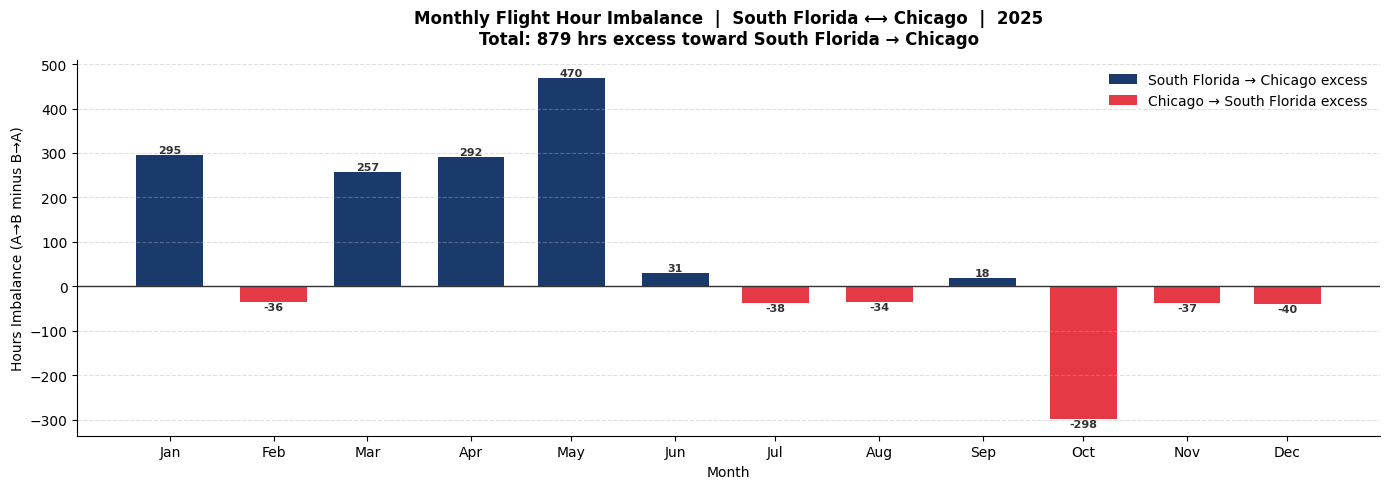

In [5]:
data = Data.copy()
SELECTED_YEAR     = 2025                        # 2023, 2024, or 2025
SELECTED_CORRIDOR = ('South Florida', 'Chicago') # (A, B)

# ── Preprocessing ──────────────────────────────────────────────────────────────
data['FlightDate_ET'] = pd.to_datetime(data['FlightDate_ET']).dt.normalize()
data['Route']         = data['FromMetro'] + '->' + data['ToMetro']

# ══════════════════════════════════════════════════════════════════════════════
# FILTER by year and corridor
# ══════════════════════════════════════════════════════════════════════════════
A, B       = SELECTED_CORRIDOR
route_ab   = f'{A}->{B}'
route_ba   = f'{B}->{A}'

data = data[
    (data['year']  == SELECTED_YEAR) &
    (data['Route'].isin([route_ab, route_ba]))
]

# ── Monthly imbalance (A→B hours minus B→A hours, per month) ──────────────────
data = data.copy()
data['Month'] = data['FlightDate_ET'].dt.to_period('M')

monthly = (
    data.groupby(['Month', 'Route'])['Hours']
    .sum()
    .unstack(fill_value=0)
)

# Ensure both columns exist
for col in [route_ab, route_ba]:
    if col not in monthly.columns:
        monthly[col] = 0

monthly['Imbalance'] = monthly[route_ab] - monthly[route_ba]
monthly.index = monthly.index.to_timestamp()

# ══════════════════════════════════════════════════════════════════════════════
# PLOT
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')

colors = ['#1a3a6b' if v >= 0 else '#e63946' for v in monthly['Imbalance']]

bars = ax.bar(
    monthly.index,
    monthly['Imbalance'],
    color=colors,
    width=20,         # width in days
    align='center'
)

# Value labels on each bar
for bar in bars:
    height = bar.get_height()
    if height == 0:
        continue
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom' if height >= 0 else 'top',
        fontsize=8,
        fontweight='bold',
        color='#333333'
    )

# Zero line
ax.axhline(0, color='#333333', linewidth=1)

# ── Legend / annotation ────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a3a6b', label=f'{A} → {B} excess'),
    Patch(facecolor='#e63946', label=f'{B} → {A} excess'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False)

# ── Total summary in subtitle ──────────────────────────────────────────────────
total_ab  = monthly[route_ab].sum()
total_ba  = monthly[route_ba].sum()
total_imb = total_ab - total_ba
direction = f'{A} → {B}' if total_imb >= 0 else f'{B} → {A}'

ax.set_title(
    f'Monthly Flight Hour Imbalance  |  {A} ⟷ {B}  |  {SELECTED_YEAR}\n'
    f'Total: {abs(total_imb):,.0f} hrs excess toward {direction}',
    fontsize=12,
    fontweight='bold',
    pad=12
)

ax.set_ylabel('Hours Imbalance (A→B minus B→A)')
ax.set_xlabel('Month')

import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Clean style
ax.grid(axis='y', linestyle='--', alpha=0.4)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()